# Preprocesamiento de Dataset — Detección de Lavado de Activos

**Semillero de Investigación — PerceptIA**  
**Equipo:** Nexus  
**Dataset:** `Datos_KIA.csv` — Registros de compra de vehículos (ASIA / KMOT)

## Descripción del dataset

Este dataset contiene **32.606 registros** y **55 columnas** correspondientes a formularios de compra de vehículos de dos marcas: ASIA y KMOT. Cada registro representa una transacción de un cliente, e incluye información demográfica, financiera, laboral y de vínculo con personas expuestas políticamente (PEP).

## Índice

1. Importación de librerías
2. Carga e inspección inicial del dataset
3. Análisis de valores nulos
4. Eliminación de columnas irrelevantes
5. Tratamiento de valores nulos
6. Conversión de tipos de datos
7. Limpieza de columnas de texto
8. Tratamiento de valores atípicos (outliers)
9. Codificación de variables categóricas
10. Normalización de variables numéricas
11. Validación final y exportación

## 1. Importación de Librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 60)

print(' Librerías importadas correctamente')

 Librerías importadas correctamente


## 2. Carga e Inspección Inicial

Esto permite:
- Conocer las dimensiones (filas y columnas).
- Identificar los tipos de datos de cada columna.
- Detectar columnas con valores nulos a simple vista.
- Obtener estadísticas descriptivas para variables numéricas.

Se utiliza `low_memory=False` para que pandas infiera correctamente los tipos de dato en columnas con entradas mixtas (por ejemplo, `coincidencias_listas_Tercero` tiene texto y valores nulos).

In [2]:
# Carga del dataset
# Si estás en Colab, primero sube el archivo con:
# from google.colab import files
# files.upload()

df = pd.read_csv('Datos KIA.csv', low_memory=False)
print(f'📊 Dimensiones del dataset: {df.shape[0]:,} filas × {df.shape[1]} columnas')

📊 Dimensiones del dataset: 32,606 filas × 55 columnas


In [3]:
# Primeras filas del dataset
df.head()

,Fecha_Formulario,Nombres_completos_cliente,Identificación,Tipo_Cliente,Fuente,Forma_Pago,Agencia_Venta,Ubicación_Agencia,Nacionalidad,Ubicación_Cliente,Fecha_nacimiento_Cliente,Nombres_Conyuge,Identificación_Conyuge,Detalle_Profesion,Actividad_Economica_RESU,Ubicación_Trabajo_Independiente,Razon_Social_Independiente,RUC_Independiente,Actividad_Empresa_Independiente,Nombre_Empresa_Dependiente,Actividad_Empresa_Dependiente,Vinculo_PEP,Total_Activos,Total_Pasivo,Total_Ingresos,Total_Gastos,Clase_Vehículo,Valor_Vehículo,Tipo_Vehiculo,Numero_VIN,Pago_Tercero,Nombre_Tercero,Identificación_Tercero,Cotización,fecha,Año,Mes,Empresa,Edad,Provincia_agencia,Canton_agencia,Provincia_residencia,Canton_residencia,bandera_tercero,categoria_economica,sujetos_obligados,identificacion_conyuge,identificacion,ID_unico,Nombres_completos_cliente_clean,Nombres_Conyuge_clean,Nombre_Tercero_clean,coincidencias_listas,coincidencias_listas_Conyuge,coincidencias_listas_Tercero
0,21/1/2025,LUIS GERARDO CONCHA ROMERO,604115865,NATURAL,WEB,CONTADO,RIOBAMBA,CHIMBORAZO - RIOBAMBA - SN,ECUATORIANA,CHIMBORAZO - RIOBAMBA - SN,3/14/1992,NO APLICA,NO APLICA,DEPENDIENTE,ACTIVIDADES DE OTRAS ASOCIACIONES,NO APLICA,NO APLICA,NO APLICA,NO APLICA,PRONACA,ACTIVIDADES DE OTRAS ASOCIACIONES,NO APLICA,30000.0,300.0,2100,250,PASAJEROS,30999,UTILITARIO,NO APLICA,ACTIVIDADES DE OTRAS ASOCIACIONES,NO APLICA,NO APLICA,01-ASIA-2022-0008654,1/21/2025,2025,1,ASIA,33.0,CHIMBORAZO,RIOBAMBA - SN,CHIMBORAZO,RIOBAMBA - SN,0,Fundaciones y ONGs,FUNDACIONES Y ONGs,NaN,NaN,01-ASIA-2022-0008654,concha gerardo luis romero,aplica no,aplica no,NaN,NaN,NaN
1,12/5/2025,OSWALDO RAMIRO GODOY ARCE,1804285128,NATURAL,SHOWROOM,CONTADO,FICOA,TUNGURAHUA - AMBATO - SN,ECUATORIANA,TUNGURAHUA - AMBATO - HUACHI CHICO,4/6/1987,ANDREA MERCEDES TORRES LOZADA,1803981040,DEPENDIENTE,EMPLEADO PRIVADO,NO APLICA,NO APLICA,NO APLICA,NO APLICA,SERTECPET,EMPLEADO PRIVADO,NO APLICA,200000.0,320.0,5000,320,PASAJEROS,21490,UTILITARIO,NO APLICA,EMPLEADO PRIVADO,NO APLICA,NO APLICA,01-ASIA-2022-0116056,5/12/2025,2025,5,ASIA,38.0,TUNGURAHUA,AMBATO - SN,TUNGURAHUA,AMBATO - HUACHI CHICO,0,Empleado privado,SIN RIESGO,NaN,NaN,01-ASIA-2022-0116056,arce godoy oswaldo ramiro,andrea lozada mercedes torres,aplica no,NaN,NaN,NaN
2,29/1/2026,SERGIO VICENTE REYES CARDENAS,1302282775,NATURAL,PROSPECCION,CONTADO,MANTA 4 NOV,MANABI - MANTA - SN,ECUATORIANA,MANABI - MANTA - MANTA,6/11/1956,NO APLICA,NO APLICA,INDEPENDIENTE,ACTIVIDADES ADMINISTRATIVAS Y DE APOYO DE OFICINA,MANABI-PORTOVIEJO MANTA,SERGIO REYES,NaN,ACTIVIDADES ADMINISTRATIVAS Y DE APOYO DE OFICINA,NO APLICA,NO APLICA,NO APLICA,424000.0,100.0,3000,200,PASAJEROS,23499,UTILITARIO,NO APLICA,ACTIVIDADES ADMINISTRATIVAS Y DE APOYO DE OFICINA,NO APLICA,NO APLICA,01-ASIA-2023-0016654,1/29/2026,2026,1,ASIA,69.0,MANABI,MANTA - SN,MANABI,MANTA - MANTA,0,Actividades de prestación de una serie de servicios admi...,SIN RIESGO,NaN,NaN,01-ASIA-2023-0016654,cardenas reyes sergio vicente,aplica no,aplica no,NaN,NaN,NaN
3,26/4/2025,JORDAN STICK SORIA PINARGOTE,1311738007,NATURAL,SHOWROOM,CONTADO,PORTOVIEJO,MANABI - PORTOVIEJO - SN,ECUATORIANA,MANABI - PORTOVIEJO - SN,6/12/1994,NO APLICA,NO APLICA,INDEPENDIENTE,COMERCIO AL POR MAYOR Y AL POR MENOR; REPARACIÓN DE VEHÍ...,MANABI-PORTOVIEJO PORTOVIEJO,ELECTRONICA,NaN,COMERCIO AL POR MAYOR Y AL POR MENOR; REPARACIÓN DE VEHÍ...,NO APLICA,NO APLICA,NO APLICA,10000.0,100.0,2000,100,PASAJEROS,16499,SEDAN,NO APLICA,COMERCIO AL POR MAYOR Y AL POR MENOR; REPARACIÓN DE VEHÍ...,NO APLICA,NO APLICA,01-ASIA-2023-0040859,4/26/2025,2025,4,ASIA,31.0,MANABI,PORTOVIEJO - SN,MANABI,PORTOVIEJO - SN,0,"Fabricación de repuestos y equipos de vehículos, motos, ...","COMERCIALIZADORAS Y FABRICADORAS DE VEHÍCULOS, MOTOS, NA...",NaN,NaN,01-ASIA-2023-0040859,jordan pinargote soria stick,aplica no,aplica no,NaN,NaN,NaN
4,21/9/2025,EDISON GIOVANNY TACO CASAMEN,1713861266,NATURAL,SHOWROOM,CREDITO,CONDADO,PICHINCHA - DISTRITO METROPOLITANO DE QUITO - PONCEANO,ECUATORIANA,PICHIN

In [4]:
# Tipos de datos y valores no nulos por columna
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32606 entries, 0 to 32605
Data columns (total 55 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Fecha_Formulario                 32606 non-null  object 
 1   Nombres_completos_cliente        32604 non-null  object 
 2   Identificación                   32606 non-null  object 
 3   Tipo_Cliente                     32606 non-null  object 
 4   Fuente                           32606 non-null  object 
 5   Forma_Pago                       32606 non-null  object 
 6   Agencia_Venta                    32606 non-null  object 
 7   Ubicación_Agencia                32606 non-null  object 
 8   Nacionalidad                     32606 non-null  object 
 9   Ubicación_Cliente                32606 non-null  object 
 10  Fecha_nacimiento_Cliente         31627 non-null  object 
 11  Nombres_Conyuge                  32606 non-null  object 
 12  Identificación_Con

In [5]:
# Estadísticas descriptivas de variables numéricas
df.describe().T.style.background_gradient(cmap='Blues')

,count,mean,std,min,25%,50%,75%,max
Total_Activos,32606.000000,90102314.649635,6039555852.051364,0.000000,6500.000000,18500.000000,80000.000000,484650000000.000000
Total_Pasivo,32606.000000,55155124.480188,4417430425.399612,0.000000,20.000000,100.000000,300.000000,356744000000.000000
Total_Ingresos,32606.000000,1402327.831381,77333054.636466,0.000000,1200.000000,1600.000000,2800.000000,12000000000.000000
Total_Gastos,32606.000000,406219.739312,31904100.752026,0.000000,40.000000,100.000000,200.000000,4000000000.000000
Valor_Vehículo,32606.000000,14635078.787953,669772015.763270,5000.000000,15999.000000,20565.000000,26499.000000,65990000000.000000
Año,32606.000000,2025.146077,0.353189,2025.000000,2025.000000,2025.000000,2025.000000,2026.000000
Mes,32606.000000,5.819052,3.561937,1.000000,2.000000,6.000000,9.000000,12.000000
Edad,31627.000000,41.930155,14.841029,1.000000,30.000000,39.000000,52.000000,95.000000
bandera_tercero,32606.000000,0.000705,0.026550,0.000000,0.000000,0.000000,0.000000,1.000000
identificacion_conyuge,0.000000,nan,nan,nan,nan,nan,nan,nan


In [6]:
# Verificación de registros duplicados
n_dup = df.duplicated().sum()
print(f'🔁 Registros duplicados: {n_dup}')
if n_dup == 0:
    print('✅ No existen registros duplicados en el dataset.')

🔁 Registros duplicados: 0
✅ No existen registros duplicados en el dataset.


## 3. Análisis de Valores Nulos

Los valores nulos representan ausencia de información y pueden provocar errores en el entrenamiento de modelos. Es fundamental cuantificarlos y visualizarlos antes de decidir qué hacer con ellos. La estrategia dependerá del **porcentaje de nulos** y de la **importancia de la variable** para el modelo.

Se clasifica el tratamiento así:

- **> 95% nulos — regla general:** la columna no aporta información útil → se elimina.
- **> 95% nulos — excepción de regla de negocio (variables de coincidencias con listas de riesgo):** aunque `coincidencias_listas`, `coincidencias_listas_Conyuge` y `coincidencias_listas_Tercero` superan el 97% de nulos, **NO se eliminan**. En el contexto de detección de lavado de activos, la ausencia de valor en estas columnas es en sí misma información predictiva: significa que el cliente, cónyuge o tercero **no aparece en ninguna lista de riesgo**. Eliminar estas columnas equivaldría a descartar una señal de alerta clave. Por tanto, los nulos se imputan con la etiqueta `'SIN_COINCIDENCIA'`, creando una categoría explícita que el modelo puede aprender a distinguir de las coincidencias reales.
- **< 10% nulos en variables clave:** se imputan con mediana (numéricas) o moda (categóricas).
- **Nulos estructurales** (por ejemplo, cónyuge en cliente soltero): se etiquetan como `'SIN_DATO'`.

In [7]:
# Tabla de nulos: cantidad y porcentaje
nulos = df.isnull().sum()
pct_nulos = (nulos / len(df) * 100).round(2)
tabla_nulos = pd.DataFrame({'Nulos': nulos, 'Porcentaje (%)': pct_nulos})
tabla_nulos = tabla_nulos[tabla_nulos['Nulos'] > 0].sort_values('Porcentaje (%)', ascending=False)

print(f'Columnas con al menos un valor nulo: {len(tabla_nulos)}')
tabla_nulos

Columnas con al menos un valor nulo: 11


,Nulos,Porcentaje (%)
identificacion,32606,100.00
identificacion_conyuge,32606,100.00
coincidencias_listas_Tercero,32604,99.99
coincidencias_listas_Conyuge,32209,98.78
coincidencias_listas,31868,97.74
Fecha_nacimiento_Cliente,979,3.00
Edad,979,3.00
RUC_Independiente,76,0.23
Nombres_completos_cliente,2,0.01
Razon_Social_Independiente,2,0.01


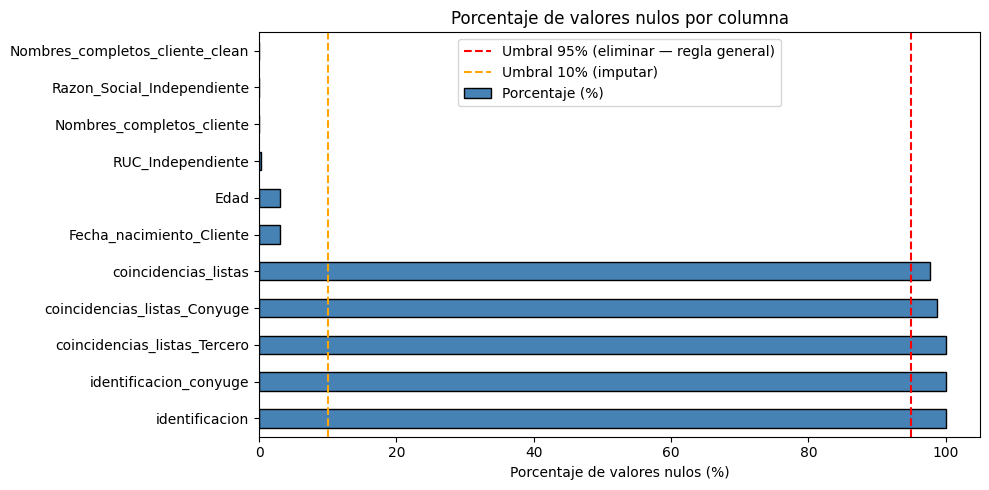

In [8]:
# Visualización de nulos
fig, ax = plt.subplots(figsize=(10, 5))
tabla_nulos['Porcentaje (%)'].plot(kind='barh', ax=ax, color='steelblue', edgecolor='black')
ax.set_xlabel('Porcentaje de valores nulos (%)')
ax.set_title('Porcentaje de valores nulos por columna')
ax.axvline(x=95, color='red', linestyle='--', label='Umbral 95% (eliminar — regla general)')
ax.axvline(x=10, color='orange', linestyle='--', label='Umbral 10% (imputar)')
ax.legend()
plt.tight_layout()
plt.show()

## 4. Eliminación de Columnas Irrelevantes o Redundantes

Se eliminan columnas que no aportan valor predictivo al modelo, por alguna de estas razones:

| Columna | Razón de eliminación |
|---|---|
| `identificacion_conyuge` | 100% nulos — no contiene ningún dato |
| `identificacion` | 100% nulos — columna completamente vacía (no confundir con `Identificación`, que sí tiene datos) |
| `Numero_VIN` | Valor único `'NO APLICA'` en todos los registros — varianza cero |
| `Cotización` | Igual a `ID_unico` — columna redundante |
| `fecha` | Duplica `Fecha_Formulario` en distinto formato |
| `Nombres_completos_cliente` | Identificador personal: no generalizable ni aportante al modelo |
| `Nombres_completos_cliente_clean` | Versión procesada del anterior — misma razón de eliminación |
| `Nombres_Conyuge` | Identificador personal del cónyuge: no generalizable |
| `Nombres_Conyuge_clean` | Versión procesada del anterior — misma razón |
| `Nombre_Tercero` | Identificador personal del tercero: no generalizable |
| `Nombre_Tercero_clean` | Versión procesada del anterior — misma razón |

> **Nota metodológica — columnas de nombres:** Los nombres completos de personas y razones sociales funcionan como identificadores únicos de cada registro. Conservarlos en el dataset predictivo introduciría ruido y provocaría *data leakage* en caso de que el modelo memorice combinaciones nombre-etiqueta del conjunto de entrenamiento, impidiendo la generalización. Se mantiene únicamente el campo `Identificación` (número de cédula/RUC) como llave de negocio para trazabilidad, pero no se incluirá como variable de entrada al modelo.
>


In [9]:
# Verificar columnas 100% nulas
cols_100_nulos = df.columns[df.isnull().mean() == 1.0].tolist()
print(f'Columnas con 100% de valores nulos: {cols_100_nulos}')

Columnas con 100% de valores nulos: ['identificacion_conyuge', 'identificacion']


In [10]:
# Verificar columna Numero_VIN (varianza cero)
print('Valores únicos en Numero_VIN:', df['Numero_VIN'].unique())
print('Valores únicos en Cotización vs ID_unico (son iguales):',
      (df['Cotización'] == df['ID_unico']).all())

Valores únicos en Numero_VIN: ['NO APLICA']
Valores únicos en Cotización vs ID_unico (son iguales): True


In [11]:
# Eliminar columnas irrelevantes o que no aportan valor predictivo generalizable
cols_eliminar = [
    'identificacion_conyuge',          # 100% nulos
    'identificacion',                  # 100% nulos (columna vacía distinta de 'Identificación')
    'Numero_VIN',                      # Varianza cero, todos 'NO APLICA'
    'Cotización',                      # Redundante con ID_unico
    'fecha',                           # Duplica Fecha_Formulario
    'Nombres_completos_cliente',       # Identificador personal — no generalizable
    'Nombres_completos_cliente_clean', # Versión procesada del anterior — misma razón
    'Nombres_Conyuge',                 # Identificador personal del cónyuge
    'Nombres_Conyuge_clean',           # Versión procesada del anterior
    'Nombre_Tercero',                  # Identificador personal del tercero
    'Nombre_Tercero_clean'             # Versión procesada del anterior
]

# Eliminar sólo las columnas que existan en el dataframe (robustez)
cols_eliminar_existentes = [c for c in cols_eliminar if c in df.columns]
df.drop(columns=cols_eliminar_existentes, inplace=True)

print(f'✅ Columnas eliminadas: {len(cols_eliminar_existentes)}')
print(f'📊 Dimensiones actuales: {df.shape[0]:,} filas × {df.shape[1]} columnas')

✅ Columnas eliminadas: 11
📊 Dimensiones actuales: 32,606 filas × 44 columnas


## 5. Tratamiento de Valores Nulos

Tras la eliminación de columnas completamente vacías y de columnas no predictivas, quedan nulos en columnas con información parcial. Se aplica la siguiente estrategia diferenciada:

| Columna | Nulos | Estrategia | Justificación |
|---|---|---|---|
| `Fecha_nacimiento_Cliente` / `Edad` | 979 (3%) | Imputar `Edad` con mediana; `Fecha_nacimiento_Cliente` con `'SIN_DATO'` | Mantiene la distribución sin perder registros |
| `Razon_Social_Independiente` | 2 (0.006%) | Imputar con `'NO APLICA'` | Consistente con el valor dominante en clientes dependientes |
| `RUC_Independiente` | 76 (0.2%) | Imputar con `'SIN_RUC'` | Clientes dependientes legítimamente no tienen RUC |
| `coincidencias_listas` | ~97.7% | Imputar con `'SIN_COINCIDENCIA'` | **Excepción de regla de negocio** (ver Paso 3): la ausencia indica que el cliente no figura en ninguna lista de riesgo, lo cual es una señal predictiva explícita |
| `coincidencias_listas_Conyuge` | ~98.8% | Imputar con `'SIN_COINCIDENCIA'` | Ídem |
| `coincidencias_listas_Tercero` | ~99.9% | Imputar con `'SIN_COINCIDENCIA'` | Ídem |

In [12]:
# Imputar Edad con la mediana
mediana_edad = df['Edad'].median()
df['Edad'].fillna(mediana_edad, inplace=True)
print(f'✅ Edad imputada con mediana: {mediana_edad:.0f} años')
print(f'   Nulos restantes en Edad: {df["Edad"].isnull().sum()}')

✅ Edad imputada con mediana: 39 años
   Nulos restantes en Edad: 0


In [13]:
# Imputar Fecha_nacimiento_Cliente con 'SIN_DATO'
df['Fecha_nacimiento_Cliente'].fillna('SIN_DATO', inplace=True)
print('✅ Fecha_nacimiento_Cliente imputada con SIN_DATO')

✅ Fecha_nacimiento_Cliente imputada con SIN_DATO


In [14]:
# Imputar campos de texto con valores coherentes
df['Razon_Social_Independiente'].fillna('NO APLICA', inplace=True)
df['RUC_Independiente'].fillna('SIN_RUC', inplace=True)

# Columnas de coincidencias con listas de riesgo
# EXCEPCIÓN DE REGLA DE NEGOCIO: nulo = sin coincidencia detectada.
# Se imputa con 'SIN_COINCIDENCIA' para que el modelo pueda distinguir
# explícitamente entre clientes limpios y clientes en listas de riesgo.
df['coincidencias_listas'].fillna('SIN_COINCIDENCIA', inplace=True)
df['coincidencias_listas_Conyuge'].fillna('SIN_COINCIDENCIA', inplace=True)
df['coincidencias_listas_Tercero'].fillna('SIN_COINCIDENCIA', inplace=True)

print('✅ Todos los valores nulos han sido tratados')
print(f'\nNulos restantes en el dataset: {df.isnull().sum().sum()}')

✅ Todos los valores nulos han sido tratados

Nulos restantes en el dataset: 0


In [15]:
# Confirmación visual —
nulos_final = df.isnull().sum()
print('Columnas con nulos restantes:')
restantes = nulos_final[nulos_final > 0]
print(restantes if len(restantes) > 0 else '✅ Ninguna')

Columnas con nulos restantes:
✅ Ninguna


## 6.  Conversión de Tipos de Datos

Es necesario convertir los tipos de datos al formato correcto:

- **Fechas** (`Fecha_Formulario`, `Fecha_nacimiento_Cliente`): Se convierten a tipo `datetime` para poder calcular variables derivadas como antigüedad del cliente o años entre transacciones.
- **`Edad`**: Convertida a entero una vez imputada.
- **Campos de identificación**: Se verifican como texto (algunos números de cédula empiezan con 0).



In [16]:
# Convertir Fecha_Formulario a datetime
df['Fecha_Formulario'] = pd.to_datetime(df['Fecha_Formulario'], dayfirst=True, errors='coerce')
print('Fecha_Formulario:', df['Fecha_Formulario'].dtype)
print('Rango de fechas:', df['Fecha_Formulario'].min(), '→', df['Fecha_Formulario'].max())

Fecha_Formulario: datetime64[ns]
Rango de fechas: 2025-01-04 00:00:00 → 2026-03-02 00:00:00


In [17]:
# Convertir Fecha_nacimiento_Cliente (ignorar 'SIN_DATO' → se convierte a NaT automáticamente)
df['Fecha_nacimiento_Cliente'] = pd.to_datetime(
    df['Fecha_nacimiento_Cliente'],
    dayfirst=True,
    errors='coerce'
)
print('Fecha_nacimiento_Cliente:', df['Fecha_nacimiento_Cliente'].dtype)

Fecha_nacimiento_Cliente: datetime64[ns]


In [18]:
# Convertir Edad a entero
df['Edad'] = df['Edad'].astype(int)

# Variable derivada: trimestre de la compra (potencialmente útil para detectar patrones estacionales)
df['Trimestre'] = df['Fecha_Formulario'].dt.quarter

print('✅ Tipos de datos actualizados')
print(df[['Fecha_Formulario', 'Fecha_nacimiento_Cliente', 'Edad', 'Trimestre']].dtypes)

✅ Tipos de datos actualizados
Fecha_Formulario            datetime64[ns]
Fecha_nacimiento_Cliente    datetime64[ns]
Edad                                 int64
Trimestre                            int32
dtype: object


## 7. Limpieza de Columnas de Texto

Las columnas de texto pueden contener inconsistencias como espacios adicionales, diferencias entre mayúsculas y minúsculas, o valores que deberían ser equivalentes pero están escritos de forma distinta (por ejemplo `'NO APLICA'` vs `'No Aplica'`). Esto afecta la codificación y puede generar categorías artificialmente distintas.

También se limpian las columnas `Provincia_agencia` y `Provincia_residencia`, que en la exploración mostraron espacios al inicio (`' RIOBAMBA'` en lugar de `'RIOBAMBA'`).

In [19]:
# Normalizar columnas de texto: strip + upper
cols_texto = df.select_dtypes(include='object').columns.tolist()
for col in cols_texto:
    df[col] = df[col].astype(str).str.strip().str.upper()

print(f'✅ {len(cols_texto)} columnas de texto normalizadas (strip + upper)')

✅ 33 columnas de texto normalizadas (strip + upper)


In [20]:
# Estandarizar variantes del valor 'SN' en ubicaciones
# 'SN' significa 'Sin Número' — puede aparecer como 'S/N', 'S.N', 'SIN NÚMERO'
for col in ['Ubicación_Agencia', 'Ubicación_Cliente', 'Canton_agencia', 'Canton_residencia']:
    antes = df[col].nunique()
    df[col] = df[col].str.replace(r'\bS\.?/?N\.?\b', 'SN', regex=True)
    despues = df[col].nunique()
    print(f'{col}: {antes} → {despues} categorías únicas')

Ubicación_Agencia: 43 → 43 categorías únicas
Ubicación_Cliente: 834 → 834 categorías únicas
Canton_agencia: 43 → 43 categorías únicas
Canton_residencia: 834 → 834 categorías únicas


In [21]:
# Corregir valor 'SN' en Vinculo_PEP
# 'SN' es casi con certeza 'NO APLICA' (dato mal ingresado)
print('Valores únicos en Vinculo_PEP:', df['Vinculo_PEP'].value_counts().to_dict())
df['Vinculo_PEP'] = df['Vinculo_PEP'].replace('SN', 'NO APLICA')
print('Después de corrección:', df['Vinculo_PEP'].value_counts().to_dict())

Valores únicos en Vinculo_PEP: {'NO APLICA': 32422, 'SI': 183, 'SN': 1}
Después de corrección: {'NO APLICA': 32423, 'SI': 183}


## 8.  Tratamiento de Valores Atípicos (Outliers)

Los outliers son valores que se alejan significativamente del comportamiento esperado de la distribución. En el contexto de lavado de activos, algunos outliers pueden ser precisamente señales de alerta (por ejemplo, un cliente declara activos de $484 billones), por lo que **no deben eliminarse indiscriminadamente**.

### Estrategia: Winsorización (Capping)

En lugar de eliminar registros, se aplica **winsorización**: los valores por encima del percentil 99 se reemplazan por el valor del percentil 99. Esto reduce el efecto distorsionador de los extremos sobre el escalado posterior, sin eliminar registros ni perder la señal de que el valor era inusualmente alto.

Variables analizadas:
- `Total_Activos`: Máximo detectado = $484.650.000.000 (señal de alerta potencial)
- `Total_Pasivo`: Máximo = $356.744.000.000
- `Total_Ingresos`: Máximo = $4.000.000.000
- `Total_Gastos`: Máximo = $12.000.000.000
- `Valor_Vehículo`: Máximo = $65.990.000.000

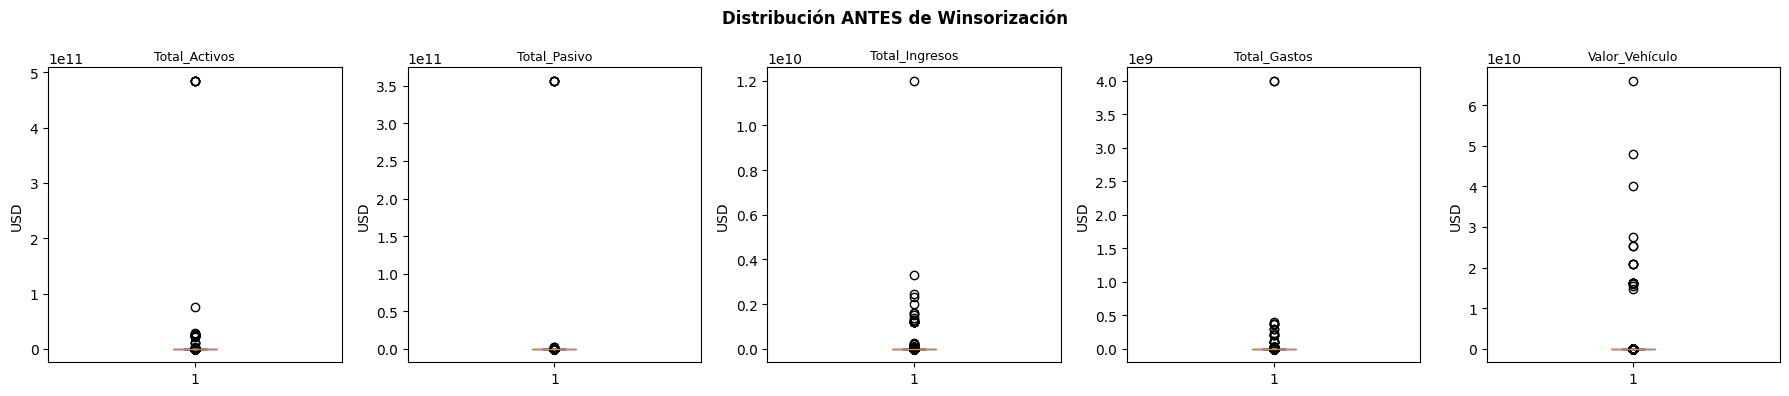

In [22]:
cols_numericas = ['Total_Activos', 'Total_Pasivo', 'Total_Ingresos', 'Total_Gastos', 'Valor_Vehículo']

# Visualizar distribución ANTES del tratamiento
fig, axes = plt.subplots(1, len(cols_numericas), figsize=(18, 4))
for i, col in enumerate(cols_numericas):
    axes[i].boxplot(df[col].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor='steelblue', color='navy'))
    axes[i].set_title(col, fontsize=9)
    axes[i].set_ylabel('USD')
fig.suptitle('Distribución ANTES de Winsorización', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [23]:
# Aplicar Winsorización al percentil 99
for col in cols_numericas:
    p99 = df[col].quantile(0.99)
    n_outliers = (df[col] > p99).sum()
    df[col] = df[col].clip(upper=p99)
    print(f'{col}: P99 = {p99:,.0f} | Registros winsorizados: {n_outliers}')

Total_Activos: P99 = 1,000,000 | Registros winsorizados: 281
Total_Pasivo: P99 = 80,000 | Registros winsorizados: 299
Total_Ingresos: P99 = 647,500 | Registros winsorizados: 327
Total_Gastos: P99 = 3,195 | Registros winsorizados: 327
Valor_Vehículo: P99 = 56,999 | Registros winsorizados: 282


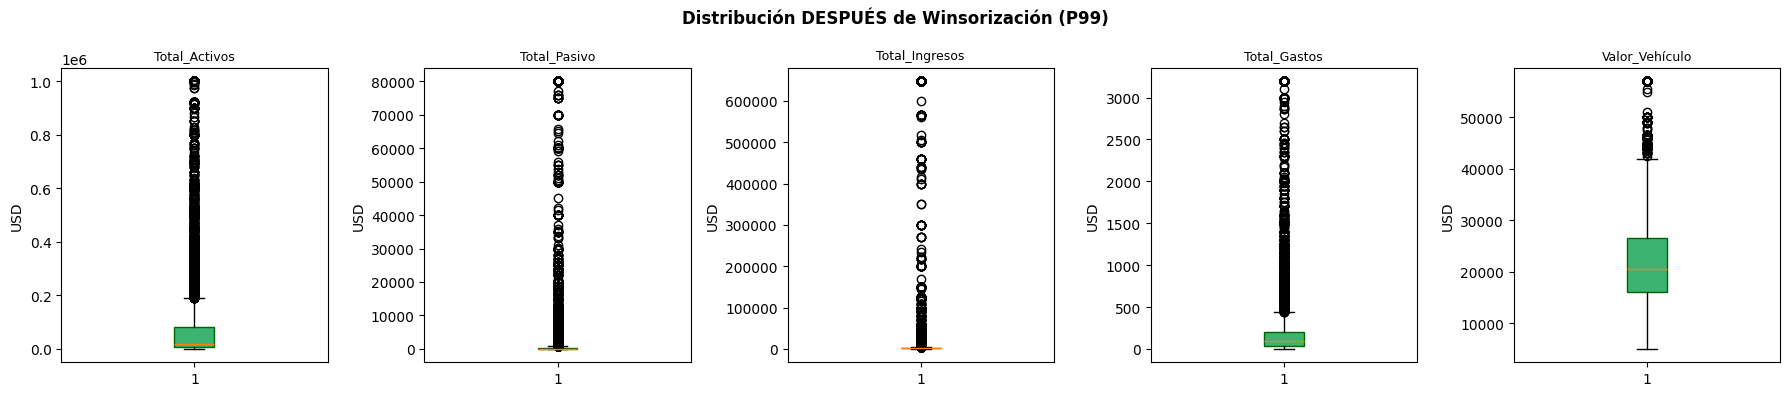

In [24]:
# Visualizar distribución DESPUÉS del tratamiento
fig, axes = plt.subplots(1, len(cols_numericas), figsize=(18, 4))
for i, col in enumerate(cols_numericas):
    axes[i].boxplot(df[col].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor='mediumseagreen', color='darkgreen'))
    axes[i].set_title(col, fontsize=9)
    axes[i].set_ylabel('USD')
fig.suptitle('Distribución DESPUÉS de Winsorización (P99)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [25]:
# Detectar y documentar registros con ingresos menores que gastos (señal de alerta)
alertas_ingreso_gasto = df[df['Total_Ingresos'] < df['Total_Gastos']]
print(f'⚠️  Registros donde Ingresos < Gastos (posible señal de alerta): {len(alertas_ingreso_gasto)}')

# Crear variable indicadora (feature para el modelo)
df['alerta_ingreso_gasto'] = (df['Total_Ingresos'] < df['Total_Gastos']).astype(int)
print(f'✅ Variable alerta_ingreso_gasto creada: {df["alerta_ingreso_gasto"].value_counts().to_dict()}')

⚠️  Registros donde Ingresos < Gastos (posible señal de alerta): 124
✅ Variable alerta_ingreso_gasto creada: {0: 32482, 1: 124}


## 9. Codificación de Variables Categóricas

Se requieren entradas numéricas. Las variables categóricas deben transformarse usando alguno de los métodos disponibles:

- **Label Encoding**: Asigna un número entero a cada categoría (ej: `CONTADO=0`, `CREDITO=1`). Se usa cuando existe un orden implícito o cuando la variable tiene pocas categorías binarias.
- **One-Hot Encoding**: Crea una columna binaria por cada categoría. Se usa cuando las categorías no tienen orden y son pocas.

Decisiones aplicadas:

| Variable | Método | Razón |
|---|---|---|
| `Forma_Pago` | Label Encoding | Binaria (CONTADO / CRÉDITO) |
| `Tipo_Cliente` | Label Encoding | Binaria (NATURAL / JURÍDICA) |
| `Vinculo_PEP` | Label Encoding | Binaria efectiva (SI / NO APLICA) |
| `Empresa` | Label Encoding | Binaria (ASIA / KMOT) |
| `bandera_tercero` | Ya binaria | Sin cambio |
| `Detalle_Profesion` | Label Encoding | 8 categorías con uso posterior en modelo |
| `coincidencias_listas` | Label Encoding | Indicador de riesgo clave |
| `coincidencias_listas_Conyuge` | Label Encoding | Ídem |
| `coincidencias_listas_Tercero` | Label Encoding | Ídem |

In [26]:
le = LabelEncoder()

cols_label = [
    'Forma_Pago',
    'Tipo_Cliente',
    'Vinculo_PEP',
    'Empresa',
    'Detalle_Profesion',
    'coincidencias_listas',
    'coincidencias_listas_Conyuge',
    'coincidencias_listas_Tercero',
    'Clase_Vehículo',
    'Tipo_Vehiculo',
    'Pago_Tercero',
    'Nacionalidad'
]

mapeos = {}
for col in cols_label:
    df[col + '_enc'] = le.fit_transform(df[col])
    mapeos[col] = dict(zip(le.classes_, le.transform(le.classes_)))
    print(f'✅ {col}: {mapeos[col]}')

✅ Forma_Pago: {'CONTADO': np.int64(0), 'CREDITO': np.int64(1)}
✅ Tipo_Cliente: {'JURIDICA': np.int64(0), 'NATURAL': np.int64(1)}
✅ Vinculo_PEP: {'NO APLICA': np.int64(0), 'SI': np.int64(1)}
✅ Empresa: {'ASIA': np.int64(0), 'KMOT': np.int64(1)}
✅ Detalle_Profesion: {'AMA DE CASA': np.int64(0), 'DEPENDIENTE': np.int64(1), 'ESTUDIANTE': np.int64(2), 'INDEPENDIENTE': np.int64(3), 'JUBILADO': np.int64(4), 'NEGOCIO INFORMAL': np.int64(5), 'NO APLICA': np.int64(6), 'SN': np.int64(7)}
✅ coincidencias_listas: {'CATASTRO FANTASMA, PEP': np.int64(0), 'CATASTRO FANTASMA, PEP POLÍTICOS': np.int64(1), 'INTERPOL': np.int64(2), 'INTERPOL,  PEP,  PEP POLÍTICOS, CATASTRO FANTASMA': np.int64(3), 'INTERPOL,  PEP,  PEP POLÍTICOS, OFAC': np.int64(4), 'INTERPOL, JUDICATURA': np.int64(5), 'INTERPOL, PEP': np.int64(6), 'INTERPOL, PEP POLÍTICOS': np.int64(7), 'JUDICATURA': np.int64(8), 'JUDICATURA,  PEP,  PEP POLÍTICOS, INTERPOL': np.int64(9), 'JUDICATURA,  PEP,  PEP POLÍTICOS, OFAC': np.int64(10), 'JUDICATURA,

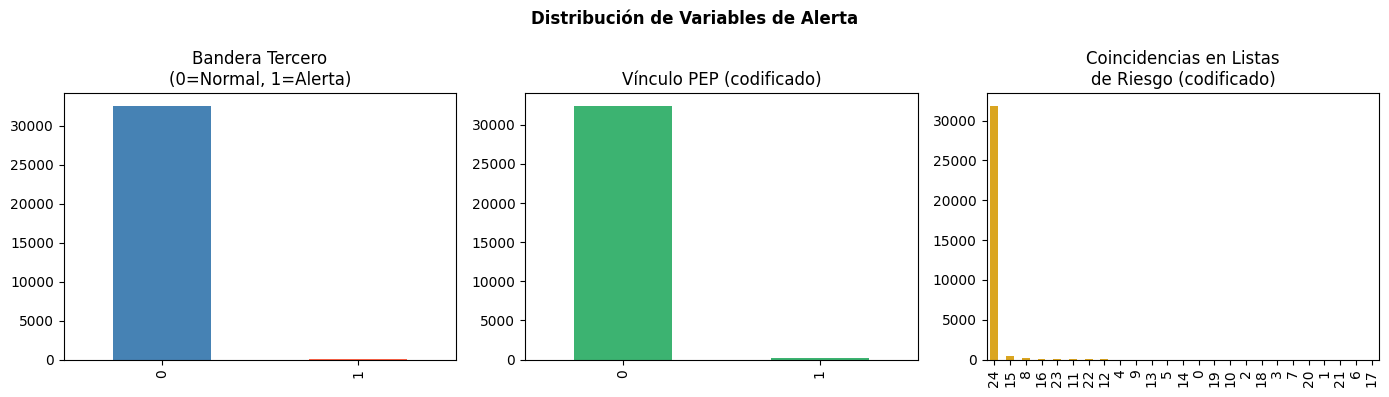

In [27]:
# Distribución de variables de alerta
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

df['bandera_tercero'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue', 'tomato'])
axes[0].set_title('Bandera Tercero\n(0=Normal, 1=Alerta)')
axes[0].set_xlabel('')

df['Vinculo_PEP_enc'].value_counts().plot(kind='bar', ax=axes[1], color='mediumseagreen')
axes[1].set_title('Vínculo PEP (codificado)')
axes[1].set_xlabel('')

df['coincidencias_listas_enc'].value_counts().plot(kind='bar', ax=axes[2], color='goldenrod')
axes[2].set_title('Coincidencias en Listas\nde Riesgo (codificado)')
axes[2].set_xlabel('')

plt.suptitle('Distribución de Variables de Alerta', fontweight='bold')
plt.tight_layout()
plt.show()

## 10. Normalización de Variables Numéricas

Las variables financieras del dataset tienen escalas muy distintas: `Edad` va de 1 a 95, mientras `Total_Activos` va de 0 a cientos de miles (tras winsorización). Esto puede hacer que modelos basados en distancia le den un peso desproporcionado a las variables de mayor magnitud.

Se aplica **MinMaxScaler**, que transforma cada valor al rango [0, 1]:

Se normalizan únicamente las columnas numéricas continuas. Las columnas categóricas ya codificadas y las variables binarias/discretas (`bandera_tercero`, `Año`, `Mes`) se mantienen sin normalizar.

In [28]:
cols_normalizar = [
    'Total_Activos',
    'Total_Pasivo',
    'Total_Ingresos',
    'Total_Gastos',
    'Valor_Vehículo',
    'Edad'
]

scaler = MinMaxScaler()
df[cols_normalizar] = scaler.fit_transform(df[cols_normalizar])

print('✅ Normalización aplicada (MinMaxScaler)')
print('\nEstadísticas tras normalización:')
display(df[cols_normalizar].describe().round(4))

# Verificar que todos los valores están en [0, 1]
for col in cols_normalizar:
    assert df[col].min() >= 0 and df[col].max() <= 1, f'❌ Error en {col}'
print('✅ Todas las variables normalizadas están en el rango [0, 1]')

✅ Normalización aplicada (MinMaxScaler)

Estadísticas tras normalización:


,Total_Activos,Total_Pasivo,Total_Ingresos,Total_Gastos,Valor_Vehículo,Edad
count,32606.0000,32606.0000,32606.0000,32606.0000,32606.0000,32606.0000
mean,0.0731,0.0216,0.0165,0.0610,0.3274,0.4345
std,0.1528,0.1171,0.1052,0.1253,0.1510,0.1556
min,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
25%,0.0065,0.0002,0.0019,0.0125,0.2115,0.3191
50%,0.0185,0.0012,0.0025,0.0313,0.2993,0.4043
75%,0.0800,0.0038,0.0043,0.0626,0.4135,0.5319
max,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000


✅ Todas las variables normalizadas están en el rango [0, 1]


## 11.  Validación Final y Exportación

Antes de exportar el dataset final se realiza una validación integral para confirmar que:
- No quedan valores nulos en las columnas que se utilizarán en el modelo.
- Los tipos de datos son correctos.
- Las dimensiones son las esperadas.
- Se documenta el resumen del proceso con cantidad de cambios realizados.



In [29]:
# Resumen del dataset final
print('=' * 55)
print('   RESUMEN DEL PREPROCESAMIENTO')
print('=' * 55)
print(f'   Filas:          {df.shape[0]:,}')
print(f'   Columnas:       {df.shape[1]}')
print(f'   Nulos totales:  {df.isnull().sum().sum()}')
print(f'   Duplicados:     {df.duplicated().sum()}')
print(f'   Memoria:        {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB')
print('=' * 55)

   RESUMEN DEL PREPROCESAMIENTO
   Filas:          32,606
   Columnas:       58
   Nulos totales:  979
   Duplicados:     0
   Memoria:        75.1 MB


In [30]:
# Vista del dataset preprocesado
df.head()

,Fecha_Formulario,Identificación,Tipo_Cliente,Fuente,Forma_Pago,Agencia_Venta,Ubicación_Agencia,Nacionalidad,Ubicación_Cliente,Fecha_nacimiento_Cliente,Identificación_Conyuge,Detalle_Profesion,Actividad_Economica_RESU,Ubicación_Trabajo_Independiente,Razon_Social_Independiente,RUC_Independiente,Actividad_Empresa_Independiente,Nombre_Empresa_Dependiente,Actividad_Empresa_Dependiente,Vinculo_PEP,Total_Activos,Total_Pasivo,Total_Ingresos,Total_Gastos,Clase_Vehículo,Valor_Vehículo,Tipo_Vehiculo,Pago_Tercero,Identificación_Tercero,Año,Mes,Empresa,Edad,Provincia_agencia,Canton_agencia,Provincia_residencia,Canton_residencia,bandera_tercero,categoria_economica,sujetos_obligados,ID_unico,coincidencias_listas,coincidencias_listas_Conyuge,coincidencias_listas_Tercero,Trimestre,alerta_ingreso_gasto,Forma_Pago_enc,Tipo_Cliente_enc,Vinculo_PEP_enc,Empresa_enc,Detalle_Profesion_enc,coincidencias_listas_enc,coincidencias_listas_Conyuge_enc,coincidencias_listas_Tercero_enc,Clase_Vehículo_enc,Tipo_Vehiculo_enc,Pago_Tercero_enc,Nacionalidad_enc
0,2025-01-21,604115865,NATURAL,WEB,CONTADO,RIOBAMBA,CHIMBORAZO - RIOBAMBA - SN,ECUATORIANA,CHIMBORAZO - RIOBAMBA - SN,1992-03-14,NO APLICA,DEPENDIENTE,ACTIVIDADES DE OTRAS ASOCIACIONES,NO APLICA,NO APLICA,NO APLICA,NO APLICA,PRONACA,ACTIVIDADES DE OTRAS ASOCIACIONES,NO APLICA,0.030,0.00375,0.003243,0.078247,PASAJEROS,0.499990,UTILITARIO,ACTIVIDADES DE OTRAS ASOCIACIONES,NO APLICA,2025,1,ASIA,0.340426,CHIMBORAZO,RIOBAMBA - SN,CHIMBORAZO,RIOBAMBA - SN,0,FUNDACIONES Y ONGS,FUNDACIONES Y ONGS,01-ASIA-2022-0008654,SIN_COINCIDENCIA,SIN_COINCIDENCIA,SIN_COINCIDENCIA,1,0,0,1,0,0,1,24,19,2,1,6,86,9
1,2025-05-12,1804285128,NATURAL,SHOWROOM,CONTADO,FICOA,TUNGURAHUA - AMBATO - SN,ECUATORIANA,TUNGURAHUA - AMBATO - HUACHI CHICO,1987-04-06,1803981040,DEPENDIENTE,EMPLEADO PRIVADO,NO APLICA,NO APLICA,NO APLICA,NO APLICA,SERTECPET,EMPLEADO PRIVADO,NO APLICA,0.200,0.00400,0.007722,0.100156,PASAJEROS,0.317121,UTILITARIO,EMPLEADO PRIVADO,NO APLICA,2025,5,ASIA,0.393617,TUNGURAHUA,AMBATO - SN,TUNGURAHUA,AMBATO - HUACHI CHICO,0,EMPLEADO PRIVADO,SIN RIESGO,01-ASIA-2022-0116056,SIN_COINCIDENCIA,SIN_COINCIDENCIA,SIN_COINCIDENCIA,2,0,0,1,0,0,1,24,19,2,1,6,217,9
2,2026-01-29,1302282775,NATURAL,PROSPECCION,CONTADO,MANTA 4 NOV,MANABI - MANTA - SN,ECUATORIANA,MANABI - MANTA - MANTA,1956-06-11,NO APLICA,INDEPENDIENTE,ACTIVIDADES ADMINISTRATIVAS Y DE APOYO DE OFICINA,MANABI-PORTOVIEJO MANTA,SERGIO REYES,SIN_RUC,ACTIVIDADES ADMINISTRATIVAS Y DE APOYO DE OFICINA,NO APLICA,NO APLICA,NO APLICA,0.424,0.00125,0.004633,0.062598,PASAJEROS,0.355757,UTILITARIO,ACTIVIDADES ADMINISTRATIVAS Y DE APOYO DE OFICINA,NO APLICA,2026,1,ASIA,0.723404,MANABI,MANTA - SN,MANABI,MANTA - MANTA,0,ACTIVIDADES DE PRESTACIÓN DE UNA SERIE DE SERVICIOS ADMI...,SIN RIESGO,01-ASIA-2023-0016654,SIN_COINCIDENCIA,SIN_COINCIDENCIA,SIN_COINCIDENCIA,1,0,0,1,0,0,3,24,19,2,1,6,0,9
3,2025-04-26,1311738007,NATURAL,SHOWROOM,CONTADO,PORTOVIEJO,MANABI - PORTOVIEJO - SN,ECUATORIANA,MANABI - PORTOVIEJO - SN,1994-06-12,NO APLICA,INDEPENDIENTE,COMERCIO AL POR MAYOR Y AL POR MENOR; REPARACIÓN DE VEHÍ...,MANABI-PORTOVIEJO PORTOVIEJO,ELECTRONICA,SIN_RUC,COMERCIO AL POR MAYOR Y AL POR MENOR; REPARACIÓN DE VEHÍ...,NO APLICA,NO APLICA,NO APLICA,0.010,0.00125,0.003089,0.031299,PASAJEROS,0.221139,SEDAN,COMERCIO AL POR MAYOR Y AL POR MENOR; REPARACIÓN DE VEHÍ...,NO APLICA,2025,4,ASIA,0.319149,MANABI,PORTOVIEJO - SN,MANABI,PORTOVIEJO - SN,0,"FABRICACIÓN DE REPUESTOS Y EQUIPOS DE VEHÍCULOS, MOTOS, ...","COMERCIALIZADORAS Y FABRICADORAS DE VEHÍCULOS, MOTOS, NA...",01-ASIA-2023-0040859,SIN_COINCIDENCIA,SIN_COINCIDENCIA,SIN_COINCIDENCIA,2,0,0,1,0,0,3,24,19,2,1,4,157,9
4,2025-09-21,1713861266,NATURAL,SHOWROOM,CREDITO,CONDADO,PICHINCHA - DISTRITO METROPOLITANO DE QUITO - PONCEANO,ECUATORIANA,PICHINCHA - DISTRITO METROPOLITANO DE QUITO - EL CONDADO,1979-05-05,NO APLICA,INDEPENDIENTE,EMPLEADO PRIVADO,PICHINCHA-DISTRITO METROPOLITANO DE QUITO LEONARDO DA VI...,PLOTER FULL,1.71386E+12,EMPLEADO PRIVADO,NO APLI

In [31]:
# Tipos de datos finales
df.dtypes

,0
Fecha_Formulario,datetime64[ns]
Identificación,object
Tipo_Cliente,object
Fuente,object
Forma_Pago,object
Agencia_Venta,object
Ubicación_Agencia,object
Nacionalidad,object
Ubicación_Cliente,object
Fecha_nacimiento_Cliente,datetime64[ns]


In [32]:
# Exportar dataset limpio
nombre_archivo = 'Datos_KIA_preprocesado.csv'
df.to_csv(nombre_archivo, index=False)
print(f'✅ Dataset exportado como: {nombre_archivo}')

from google.colab import files
files.download(nombre_archivo)

✅ Dataset exportado como: Datos_KIA_preprocesado.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>